--- Лабораторная работа № 7: Модель распространения рекламы ---

In [2]:
using DifferentialEquations, Plots, LaTeXStrings

============================================================================
Модель распространения рекламы:
  dn/dt = (α₁(t) + α₂(t)·n(t))·(N - n(t))
где:
  n(t) - число информированных клиентов в момент времени t
  N - общее число потенциальных платежеспособных покупателей
  α₁(t) - интенсивность платной рекламы
  α₂(t) - интенсивность "сарафанного радио"
============================================================================

Параметры модели

In [5]:
N0 = 5          # начальное число знающих о салоне (в момент открытия)
N = 1000        # общее число потенциальных клиентов в районе
tspan = (0.0, 60.0)  # временной промежуток (дни)

println("\n" * "="^60)
println("Модель распространения рекламы: Салон красоты")
println("="^60)
println("N0 = $N0  (начальное число знающих клиентов)")
println("N = $N    (общее число потенциальных клиентов)")


Модель распространения рекламы: Салон красоты
N0 = 5  (начальное число знающих клиентов)
N = 1000    (общее число потенциальных клиентов)


============================================================================
Задание 1: Построение графика распространения рекламы (базовый случай)
============================================================================

In [7]:
println("\n" * "="^60)
println("Задание 1: График распространения рекламы")
println("="^60)


Задание 1: График распространения рекламы


Базовые коэффициенты

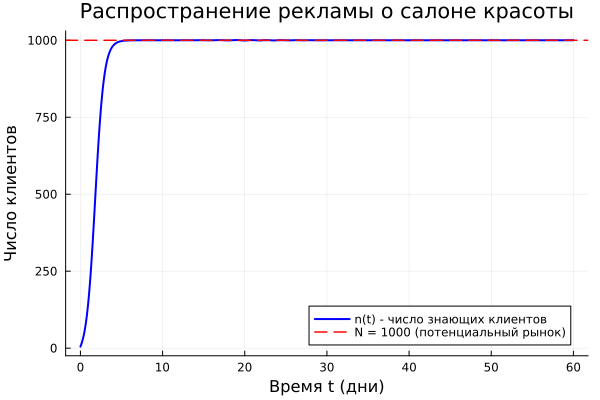

In [9]:
α₁_const = 0.055   # интенсивность платной рекламы (постоянная)
α₂_const = 0.0018  # интенсивность сарафанного радио (постоянная)

function advertising!(du, u, p, t)
    α₁, α₂, N_max = p
    n = u[1]
    du[1] = (α₁ + α₂ * n) * (N_max - n)
end

u0 = [Float64(N0)]
params_base = (α₁_const, α₂_const, N)

prob_base = ODEProblem(advertising!, u0, tspan, params_base)
sol_base = solve(prob_base, saveat=0.1)

t_vals = sol_base.t
n_vals = [u[1] for u in sol_base.u]

plot1 = plot(t_vals, n_vals,
             label="n(t) - число знающих клиентов",
             xlabel="Время t (дни)", ylabel="Число клиентов",
             title="Распространение рекламы о салоне красоты",
             linewidth=2, color=:blue)
hline!(plot1, [N], label="N = $N (потенциальный рынок)",
       color=:red, linestyle=:dash, linewidth=1.5)

display(plot1)

============================================================================
Задание 2: Сравнение эффективности при α₁ > α₂ и α₁ < α₂
============================================================================

In [11]:
println("\n" * "="^60)
println("Задание 2: Сравнение эффективности рекламной кампании")
println("="^60)


Задание 2: Сравнение эффективности рекламной кампании


Случай 1: α₁ > α₂ (преобладает платная реклама)

In [13]:
α₁_dominant = 0.1
α₂_dominant = 0.002

0.002

Случай 2: α₁ < α₂ (преобладает сарафанное радио)

In [15]:
α₁_weak = 0.02
α₂_weak = 0.008

0.008

Решение для случая с преобладанием платной рекламы

In [17]:
params_dominant = (α₁_dominant, α₂_dominant, N)
prob_dominant = ODEProblem(advertising!, u0, tspan, params_dominant)
sol_dominant = solve(prob_dominant, saveat=0.1)
n_dominant = [u[1] for u in sol_dominant.u]

601-element Vector{Float64}:
   5.0
  17.031805568919737
  31.480146024517857
  48.729935386525604
  69.18229276466995
  93.23323454072069
 121.24535205756027
 153.50547334876677
 190.182797389399
 231.2733933840553
 276.56036855028145
 325.5743735224811
 377.596097925648
   ⋮
 999.9995319500292
 999.9995583972864
 999.9995853319456
 999.999612754007
 999.9996406634706
 999.9996690603364
 999.9996979446042
 999.9997273162744
 999.9997571753465
 999.999787521821
 999.9998183556975
 999.9998496769762

Решение для случая с преобладанием сарафанного радио

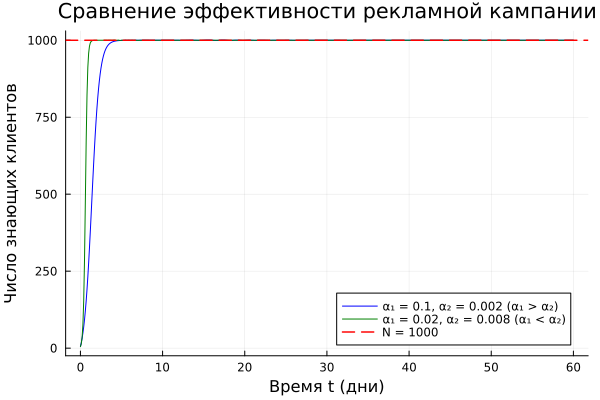

In [19]:
params_weak = (α₁_weak, α₂_weak, N)
prob_weak = ODEProblem(advertising!, u0, tspan, params_weak)
sol_weak = solve(prob_weak, saveat=0.1)
n_weak = [u[1] for u in sol_weak.u]

plot2 = plot(title="Сравнение эффективности рекламной кампании",
             xlabel="Время t (дни)", ylabel="Число знающих клиентов",
             legend=:bottomright, linewidth=2)

plot!(plot2, t_vals, n_dominant,
      label="α₁ = $α₁_dominant, α₂ = $α₂_dominant (α₁ > α₂)", color=:blue)
plot!(plot2, t_vals, n_weak,
      label="α₁ = $α₁_weak, α₂ = $α₂_weak (α₁ < α₂)", color=:green)
hline!(plot2, [N], label="N = $N", color=:red, linestyle=:dash, linewidth=1.5)

display(plot2)

============================================================================
Задание 3: Определение момента максимальной скорости роста
============================================================================

In [21]:
println("\n" * "="^60)
println("Задание 3: Момент максимальной скорости роста")
println("="^60)


Задание 3: Момент максимальной скорости роста


Скорость роста: dn/dt

In [23]:
speed = [ (α₁_const + α₂_const * n) * (N - n) for n in n_vals ]

601-element Vector{Float64}:
  63.68
  75.59239007147677
  89.48879115897522
 105.59837548632063
 124.13423023731491
 145.2719989943392
 169.1207399136074
 195.6885075489221
 224.83772370171658
 256.24562161705165
 289.3578463820044
 323.36075972313256
 357.1786995303778
   ⋮
   0.0010451947382019945
   0.0009924969150225003
   0.0009381735884759073
   0.0008822247587068462
   0.0008246504250080994
   0.0007654505872968226
   0.0007046252452709899
   0.0006421743986202824
   0.0005780980468151993
   0.0005123961899506134
   0.0004450688272695491
   0.0003761159588502932

Находим максимум скорости и соответствующий момент времени

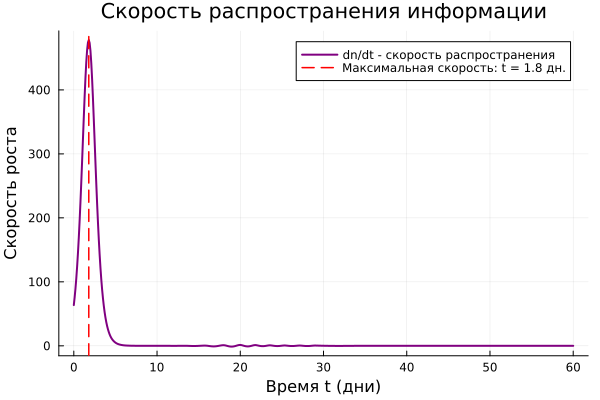


Результаты анализа скорости роста:
Максимальная скорость распространения: 477.91 клиентов/день
Время достижения максимальной скорости: 1.8 дней
Количество знающих клиентов в этот момент: 487.0 из 1000


In [25]:
max_speed, idx_max = findmax(speed)
t_max_speed = t_vals[idx_max]
n_at_max_speed = n_vals[idx_max]

plot3 = plot(t_vals, speed,
             label="dn/dt - скорость распространения",
             xlabel="Время t (дни)", ylabel="Скорость роста",
             title="Скорость распространения информации",
             linewidth=2, color=:purple)

vline!(plot3, [t_max_speed], label="Максимальная скорость: t = $(round(t_max_speed, digits=2)) дн.",
       color=:red, linestyle=:dash, linewidth=1.5)

display(plot3)

println("\nРезультаты анализа скорости роста:")
println("Максимальная скорость распространения: $(round(max_speed, digits=2)) клиентов/день")
println("Время достижения максимальной скорости: $(round(t_max_speed, digits=2)) дней")
println("Количество знающих клиентов в этот момент: $(round(n_at_max_speed, digits=0)) из $N")

============================================================================
Задание 4: Учет только платной рекламы (α₂ = 0)
============================================================================


Задание 4: Только платная реклама (α₂ = 0)


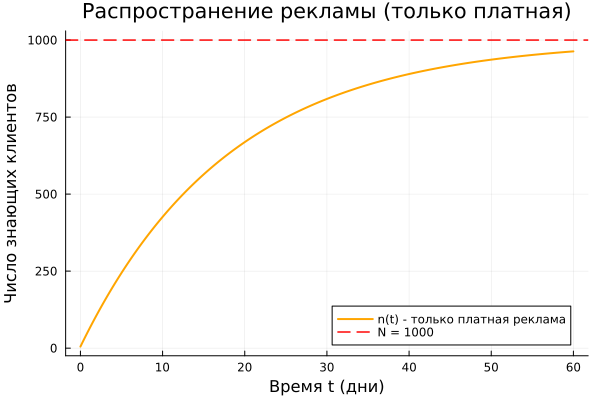

In [27]:
println("\n" * "="^60)
println("Задание 4: Только платная реклама (α₂ = 0)")
println("="^60)

α₁_only = 0.055
α₂_only = 0.0

params_only_paid = (α₁_only, α₂_only, N)
prob_only_paid = ODEProblem(advertising!, u0, tspan, params_only_paid)
sol_only_paid = solve(prob_only_paid, saveat=0.1)
n_only_paid = [u[1] for u in sol_only_paid.u]

plot4 = plot(t_vals, n_only_paid,
             label="n(t) - только платная реклама",
             xlabel="Время t (дни)", ylabel="Число знающих клиентов",
             title="Распространение рекламы (только платная)",
             linewidth=2, color=:orange)
hline!(plot4, [N], label="N = $N", color=:red, linestyle=:dash, linewidth=1.5)

display(plot4)

============================================================================
Задание 5: Только "сарафанное радио" (α₁ = 0) и сравнение
============================================================================

In [29]:
println("\n" * "="^60)
println("Задание 5: Только \"сарафанное радио\" (α₁ = 0)")
println("="^60)

α₁_word_of_mouth = 0.0
α₂_word_of_mouth = 0.005

params_only_word = (α₁_word_of_mouth, α₂_word_of_mouth, N)
prob_only_word = ODEProblem(advertising!, u0, tspan, params_only_word)
sol_only_word = solve(prob_only_word, saveat=0.1)
n_only_word = [u[1] for u in sol_only_word.u]


Задание 5: Только "сарафанное радио" (α₁ = 0)


601-element Vector{Float64}:
   5.0
   8.216950583857614
  13.475630876480164
  22.02500926660146
  35.80147927090869
  57.68661083089919
  91.67704398866674
 142.6678921609735
 215.29668609170622
 311.4680792269889
 427.19464043768875
 551.5068818065656
 669.6500140276546
   ⋮
 999.9999972811963
 999.9999973970175
 999.9999975288008
 999.9999976765464
 999.9999978402543
 999.9999980199243
 999.9999982155565
 999.999998427151
 999.9999986547076
 999.9999988982265
 999.9999991577075
 999.9999994331508

Сравнение трех вариантов: комбинированный, только платный, только сарафанное радио

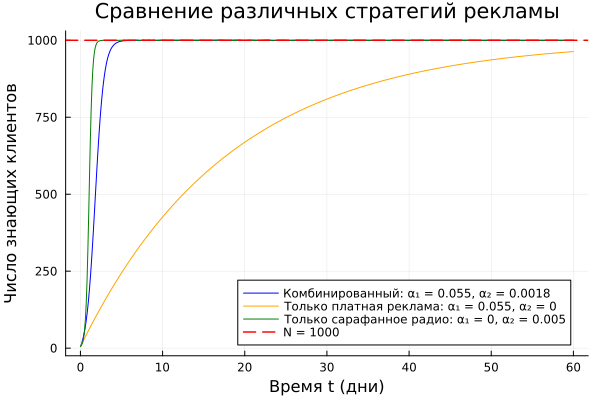

In [31]:
plot5 = plot(title="Сравнение различных стратегий рекламы",
             xlabel="Время t (дни)", ylabel="Число знающих клиентов",
             legend=:bottomright, linewidth=2)

plot!(plot5, t_vals, n_vals,
      label="Комбинированный: α₁ = $α₁_const, α₂ = $α₂_const", color=:blue)
plot!(plot5, t_vals, n_only_paid,
      label="Только платная реклама: α₁ = $α₁_only, α₂ = 0", color=:orange)
plot!(plot5, t_vals, n_only_word,
      label="Только сарафанное радио: α₁ = 0, α₂ = $α₂_word_of_mouth", color=:green)
hline!(plot5, [N], label="N = $N", color=:red, linestyle=:dash, linewidth=1.5)

display(plot5)

============================================================================
Дополнительный анализ: сравнение с логистической кривой
============================================================================

In [33]:
println("\n" * "="^60)
println("Дополнительный анализ: Сравнение с логистической кривой")
println("="^60)


Дополнительный анализ: Сравнение с логистической кривой


Логистическая кривая: dn/dt = r·n·(1 - n/N)
При α₁ = 0 и α₂ = r/N получаем уравнение логистической кривой

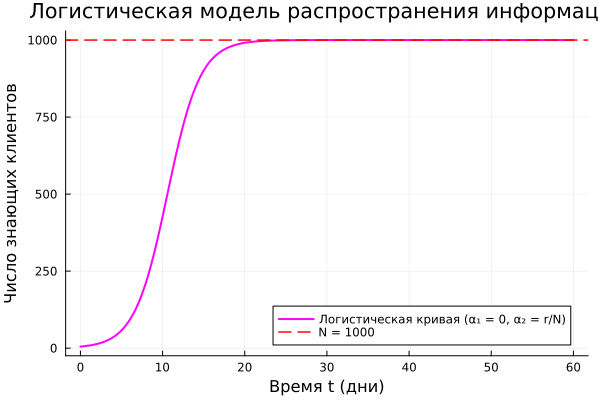

In [35]:
r_logistic = 0.5
α₁_logistic = 0.0
α₂_logistic = r_logistic / N

params_logistic = (α₁_logistic, α₂_logistic, N)
prob_logistic = ODEProblem(advertising!, u0, tspan, params_logistic)
sol_logistic = solve(prob_logistic, saveat=0.1)
n_logistic = [u[1] for u in sol_logistic.u]

plot6 = plot(t_vals, n_logistic,
             label="Логистическая кривая (α₁ = 0, α₂ = r/N)",
             xlabel="Время t (дни)", ylabel="Число знающих клиентов",
             title="Логистическая модель распространения информации",
             linewidth=2, color=:magenta)
hline!(plot6, [N], label="N = $N", color=:red, linestyle=:dash, linewidth=1.5)

display(plot6)

============================================================================
Выводы и анализ
============================================================================

In [37]:
println("\n" * "="^60)
println("АНАЛИЗ РЕЗУЛЬТАТОВ")
println("="^60)

println("\n1. Влияние коэффициентов α₁ и α₂:")
println("   • α₁ (платная реклама) - обеспечивает быстрый старт, линейный рост на начальном этапе")
println("   • α₂ (сарафанное радио) - создает эффект самовозрастания, ускоряет рост по мере увеличения числа знающих")

println("\n2. Сравнение стратегий:")
println("   • При α₁ > α₂: быстрый начальный рост, затем плавное насыщение")
println("   • При α₁ < α₂: медленный старт, но затем более крутой подъем благодаря эффекту виральности")

println("\n3. Максимальная скорость роста:")
println("   • Достигается при n = N/2 (половина потенциального рынка)")
println("   • В нашем примере: t = $(round(t_max_speed, digits=2)) дней")
println("   • Это момент наибольшей эффективности рекламной кампании")

println("\n4. Только платная реклама (α₂ = 0):")
println("   • Уравнение принимает вид: dn/dt = α₁·(N - n)")
println("   • Это модель Мальтуса с насыщением")
println("   • Решение: n(t) = N - (N - N₀)·exp(-α₁·t)")

println("\n5. Только сарафанное радио (α₁ = 0):")
println("   • Уравнение принимает вид: dn/dt = α₂·n·(N - n)")
println("   • Это логистическое уравнение")
println("   • Решение: n(t) = N / (1 + (N/N₀ - 1)·exp(-α₂·N·t))")

println("\n6. Практические рекомендации:")
println("   • На начальном этапе важна платная реклама для быстрого старта")
println("   • После достижения критической массы (≈30-50% рынка) сарафанное радио становится доминирующим")
println("   • Оптимальная стратегия: сочетание обоих каналов распространения")


АНАЛИЗ РЕЗУЛЬТАТОВ

1. Влияние коэффициентов α₁ и α₂:
   • α₁ (платная реклама) - обеспечивает быстрый старт, линейный рост на начальном этапе
   • α₂ (сарафанное радио) - создает эффект самовозрастания, ускоряет рост по мере увеличения числа знающих

2. Сравнение стратегий:
   • При α₁ > α₂: быстрый начальный рост, затем плавное насыщение
   • При α₁ < α₂: медленный старт, но затем более крутой подъем благодаря эффекту виральности

3. Максимальная скорость роста:
   • Достигается при n = N/2 (половина потенциального рынка)
   • В нашем примере: t = 1.8 дней
   • Это момент наибольшей эффективности рекламной кампании

4. Только платная реклама (α₂ = 0):
   • Уравнение принимает вид: dn/dt = α₁·(N - n)
   • Это модель Мальтуса с насыщением
   • Решение: n(t) = N - (N - N₀)·exp(-α₁·t)

5. Только сарафанное радио (α₁ = 0):
   • Уравнение принимает вид: dn/dt = α₂·n·(N - n)
   • Это логистическое уравнение
   • Решение: n(t) = N / (1 + (N/N₀ - 1)·exp(-α₂·N·t))

6. Практические рекомендаци

============================================================================
Дополнительный график: все решения вместе для наглядности
============================================================================

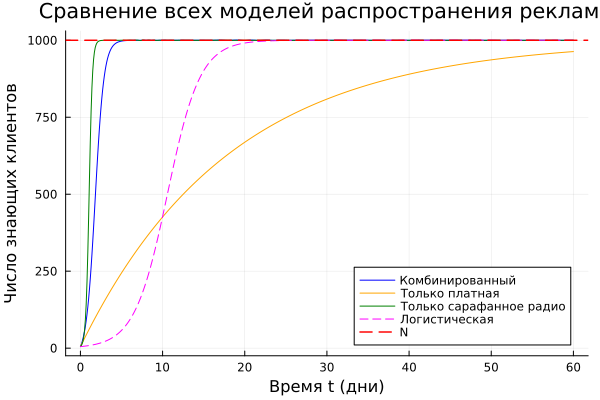

In [39]:
plot_all = plot(title="Сравнение всех моделей распространения рекламы",
                xlabel="Время t (дни)", ylabel="Число знающих клиентов",
                legend=:bottomright, linewidth=2)

plot!(plot_all, t_vals, n_vals, label="Комбинированный", color=:blue)
plot!(plot_all, t_vals, n_only_paid, label="Только платная", color=:orange)
plot!(plot_all, t_vals, n_only_word, label="Только сарафанное радио", color=:green)
plot!(plot_all, t_vals, n_logistic, label="Логистическая", color=:magenta, linestyle=:dash)
hline!(plot_all, [N], label="N", color=:red, linestyle=:dash, linewidth=1.5)

display(plot_all)